In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


# Initialization

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [3]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
PATH = "/kaggle/input/competitions/ieee-fraud-detection/"

In [5]:
import mlflow
import dagshub

dagshub.init(repo_owner='ZukaCS', repo_name='ML_assignment_2', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d9eda39e-662f-4476-bd3f-93ca3a5a746f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=33f61cd3beefabf71f0f4dd40ce52ae99bd5affd7ecf760f1b602b6e2b095c65




Accessing as ZukaCS

Initialized MLflow to track repo "ZukaCS/ML_assignment_2"

Repository ZukaCS/ML_assignment_2 initialized!

In [9]:
import mlflow
import mlflow.sklearn
import gc
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin


EXPERIMENT_NAME = "XGBoost_Training_v1.1"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

2026/05/07 11:26:04 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training_v1.1' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow
Experiment: XGBoost_Training_v1.1


In [10]:

train_tx = pd.read_csv(PATH + "train_transaction.csv")
train_id = pd.read_csv(PATH + "train_identity.csv")

train = train_tx.merge(train_id, on="TransactionID", how="left")

print(f"Train shape: {train.shape}")
print(f"Fraud rate: {train['isFraud'].mean():.4f}")
train.head()

Train shape: (590540, 434)
Fraud rate: 0.0350


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [11]:
y = train['isFraud']
X = train.drop(columns=['isFraud']) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"test fraud rate:   {y_test.mean():.4f}")



Train: 472,432 rows | Test: 118,108 rows
Train fraud rate: 0.0350
test fraud rate:   0.0350


# Data cleaning /preprocessing

In [12]:
class UselessColumnRemover(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop=None):
        self.cols_to_drop = cols_to_drop if cols_to_drop is not None else ['TransactionID']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns],
                      errors='ignore').copy()


In [13]:
class MissingValueHandler(BaseEstimator, TransformerMixin):

    def __init__(self, missing_threshold=0.75):
        self.missing_threshold = missing_threshold
        self.cols_to_drop_ = None
        self.cols_to_flag_ = None

    def fit(self, X, y=None):
        missing_rate = X.isnull().mean()
        self.cols_to_drop_ = missing_rate[missing_rate > self.missing_threshold].index.tolist()
        self.cols_to_flag_ = missing_rate[
            (missing_rate > 0.25) & (missing_rate <= self.missing_threshold)
        ].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols_to_flag_:
            if col in X.columns:
                X[col + '_missing'] = X[col].isnull().astype(np.int8)
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        return X

# Feature engineering

In [16]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, verbose=True):
        self.user_stats_ = None
        self.verbose = verbose

    def _log(self, msg):
        if self.verbose:
            print(msg)

    def fit(self, X, y=None):
        X = X.copy()
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            X['_user_id'] = self._make_user_id(X)
            self.user_stats_ = (
                X.groupby('_user_id')['TransactionAmt']
                 .agg(['count', 'mean', 'std'])
                 .rename(columns={'count': 'user_tr_count',
                                  'mean':  'user_amt_mean',
                                  'std':   'user_amt_standart_dev'})
            )
            self._log(f"Fitted user_stats on {len(self.user_stats_):,} unique users")
        else:
            self._log("Skipping user_stats fit — card1 or TransactionAmt missing")
        return self

    def transform(self, X):
        X = X.copy()
        skipped = []
        added = []

        if 'TransactionAmt' in X.columns:
            X['TransactionAmt_logarithm']   = np.log1p(X['TransactionAmt'])
            X['TransactionAmt_cents'] = X['TransactionAmt'] % 1
            added += ['TransactionAmt_logarithm', 'TransactionAmt_cents']
        else:
            skipped += ['TransactionAmt_logarithm', 'TransactionAmt_cents']

        if 'P_emaildomain' in X.columns and 'R_emaildomain' in X.columns:
            X['email_match'] = (X['P_emaildomain'] == X['R_emaildomain']).astype(np.int8)
            added += ['email_match']
        else:
            skipped += ['email_match']

        if 'TransactionDT' in X.columns:
            X['hour_of_transaction'] = (X['TransactionDT'] // 3600) % 24
            X['day_of_transaction']  = (X['TransactionDT'] // (3600 * 24)) % 7
            added += ['hour_of_transaction', 'day_of_transaction']
        else:
            skipped += ['hour_of_transaction', 'day_of_transaction']

        if 'card1' in X.columns and 'TransactionAmt' in X.columns and self.user_stats_ is not None:
            X['_user_id'] = self._make_user_id(X)
            X = X.join(self.user_stats_, on='_user_id')
            X['user_amt_standart_dev']  = X['user_amt_standart_dev'].fillna(0)
            X['user_amt_zscore'] = (
                (X['TransactionAmt'] - X['user_amt_mean']) /
                X['user_amt_standart_dev'].replace(0, 1)
            ).clip(-5, 5)
            X['user_tr_count_logarithm'] = np.log1p(X['user_tr_count'])
            X = X.drop(columns=['_user_id'])
            added += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                      'user_amt_zscore', 'user_tr_count_logarithm']
        else:
            skipped += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                        'user_amt_zscore', 'user_tr_count_logarithm']

        self._log(f"Added {len(added)} features: {added}")
        if skipped:
            self._log(f"Skipped {len(skipped)} features (missing source cols): {skipped}")

        return X

    @staticmethod
    def _make_user_id(X):
        return (
            X['card1'].fillna(-1).astype(str) + '_' +
            X.get('card2', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('addr1', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('P_emaildomain', pd.Series('unknown', index=X.index)).fillna('unknown').astype(str)
        )

In [17]:
from sklearn.preprocessing import LabelEncoder

class MyCategoricalEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.encoders_ = {}
        self.cat_cols_ = None

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include=['object']).columns.tolist()
        for col in self.cat_cols_:
            le = LabelEncoder()
            vals = X[col].fillna('missing').astype(str)
            classes = list(np.unique(vals))
            if 'missing' not in classes:
                classes.append('missing')
            le.classes_ = np.array(sorted(classes))
            self.encoders_[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cat_cols_:
            if col in X.columns:
                vals = X[col].fillna('missing').astype(str)
                known = set(self.encoders_[col].classes_)
                vals = vals.apply(lambda v: v if v in known else 'missing')
                X[col] = self.encoders_[col].transform(vals)
        return X



## Check different cleaning thresholds on baseline model

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
def quick_xgb_eval_with_threshold(X_train_raw, y_train, X_test_raw, y_test, threshold, scale_pos_weight):
    
    pre_pipeline = Pipeline([
        ('drop_useless', UselessColumnRemover(cols_to_drop=['TransactionID'])),
        ('missing',      MissingValueHandler(missing_threshold=threshold)),
        ('fe',           FeatureAdder(verbose=False)),
        ('encoder',      MyCategoricalEncoder()),
    ])
    
    X_tr = pre_pipeline.fit_transform(X_train_raw, y_train)
    X_te = pre_pipeline.transform(X_test_raw)
    
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        eval_metric='auc',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_tr, y_train)
    
    train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_te)[:, 1])
    
    return train_auc, test_auc, X_tr.shape[1]


configs_cleaning = [
    {'threshold': 0.50,  'name': '0.5 threshold'},
    {'threshold': 0.75,  'name': '0.75 threshold'},
    {'threshold': 0.95,  'name': '0.95 threshold'},
    {'threshold': 1.01,  'name': 'no_drop'},
]

print("Testing missing threshold strategies for XGBoost...\n")
cleaning_results = []

for cfg in configs_cleaning:
    print(f"Threshold = {cfg['threshold']} ({cfg['name']})...")
    
    train_auc, test_auc, n_features = quick_xgb_eval_with_threshold(
        X_train, y_train, X_test, y_test,
        cfg['threshold'], scale_pos_weight,
    )
    
    result = {
        'threshold':  cfg['threshold'],
        'name':       cfg['name'],
        'n_features': n_features,
        'train_auc':  train_auc,
        'test_auc':   test_auc,
        'auc_diff':   train_auc - test_auc,
    }
    cleaning_results.append(result)
    
    with mlflow.start_run(run_name=f"XGB_Cleaning_{cfg['name']}"):
        mlflow.log_param("missing_threshold", cfg['threshold'])
        mlflow.log_param("strategy_name",     cfg['name'])
        mlflow.log_metric("n_features",  n_features)
        mlflow.log_metric("train_auc",   train_auc)
        mlflow.log_metric("test_auc",    test_auc)
        mlflow.log_metric("auc_diff",    train_auc - test_auc)
    
    print(f"   Features: {n_features:>3} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Diff: {train_auc-test_auc:+.4f}\n")


cleaning_results = sorted(cleaning_results, key=lambda r: r['test_auc'], reverse=True)
best_threshold = cleaning_results[0]['threshold']

print(f"=== Cleaning threshold comparison ===")
for r in cleaning_results:
    print(f"  threshold={r['threshold']:<5} ({r['name']:<11}) | features={r['n_features']:>3} | test AUC: {r['test_auc']:.4f}")

print(f"\nBest threshold: {best_threshold}")

scale_pos_weight: 27.58
Testing missing threshold strategies for XGBoost...

Threshold = 0.5 (0.5 threshold)...
🏃 View run XGB_Cleaning_0.5 threshold at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/152d1ab88499473395ff34071ca2e798
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
   Features: 265 | Train AUC: 0.9642 | Test AUC: 0.9422 | Diff: +0.0220

Threshold = 0.75 (0.75 threshold)...
🏃 View run XGB_Cleaning_0.75 threshold at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/2ee80276c23c499b92e39e613f4751b8
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
   Features: 277 | Train AUC: 0.9656 | Test AUC: 0.9428 | Diff: +0.0229

Threshold = 0.95 (0.95 threshold)...
🏃 View run XGB_Cleaning_0.95 threshold at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/73badee2a1c543c9a7b17db9d999358a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_

## Log all stages

In [19]:
with mlflow.start_run(run_name="XGB_Cleaning"):
    remover = UselessColumnRemover(cols_to_drop=['TransactionID'])
    cleaner = MissingValueHandler(missing_threshold=best_threshold)
    
    X_train_clean = remover.fit_transform(X_train)
    X_train_clean = cleaner.fit_transform(X_train_clean)
    X_test_clean  = remover.transform(X_test)
    X_test_clean  = cleaner.transform(X_test_clean)
    
    mlflow.log_param("missing_threshold",     best_threshold)
    mlflow.log_param("dropped_useless_cols",  str(remover.cols_to_drop))
    mlflow.log_metric("cols_dropped_missing", len(cleaner.cols_to_drop_))
    mlflow.log_metric("missing_flags_added",  len(cleaner.cols_to_flag_))
    mlflow.log_metric("cols_remaining",       X_train_clean.shape[1])
    print(f"Cleaned: {X_train_clean.shape[1]} cols")


with mlflow.start_run(run_name="XGB_Feature_Engineering"):
    fe = FeatureAdder(verbose=False)
    fe.fit(X_train_clean)
    X_train_fe = fe.transform(X_train_clean)
    X_test_fe  = fe.transform(X_test_clean)
    
    mlflow.log_param("user_id_components", "card1_card2_addr1_P_emaildomain")
    mlflow.log_param("features_added",     "log_amt, cents, hour, day, user_aggs")
    mlflow.log_metric("n_features_after_fe", X_train_fe.shape[1])
    print(f"After FE: {X_train_fe.shape[1]} cols")


with mlflow.start_run(run_name="XGB_Categorical_Encoding"):
    encoder = MyCategoricalEncoder()
    encoder.fit(X_train_fe)
    X_train_enc = encoder.transform(X_train_fe)
    X_test_enc  = encoder.transform(X_test_fe)
    
    mlflow.log_param("encoding_strategy", "label_encoding")
    mlflow.log_metric("n_categorical_cols", len(encoder.cat_cols_))
    mlflow.log_metric("n_features_after",   X_train_enc.shape[1])
    print(f"After encoding: {X_train_enc.shape[1]} cols, NaN remaining: {X_train_enc.isnull().sum().sum()}")

Cleaned: 268 cols
🏃 View run XGB_Cleaning at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/b3e0048ea605497e8231524659dac359
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
After FE: 277 cols
🏃 View run XGB_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/0890217903c940bd9afb684a0337c045
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
After encoding: 277 cols, NaN remaining: 10681614
🏃 View run XGB_Categorical_Encoding at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/63a0041e6595435f97a970883caea25e
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4


# Training

In [20]:
X_train_sel = X_train_enc
X_test_sel  = X_test_enc
print(f"Final preprocessed shape: train {X_train_sel.shape}, test {X_test_sel.shape}")

Final preprocessed shape: train (472432, 277), test (118108, 277)


# Hyperparam tuning and logging

In [23]:
configs = [
    # few trees, small depth underfit
    {'n_estimators': 50,  'max_depth': 2,  'learning_rate': 0.01,
     'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0,  'reg_lambda': 1},    
    # normal
    {'n_estimators': 200, 'max_depth': 6,  'learning_rate': 0.1,
     'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0,  'reg_lambda': 1},
    {'n_estimators': 300, 'max_depth': 6,  'learning_rate': 0.1,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0,  'reg_lambda': 1},
    

    {'n_estimators': 500, 'max_depth': 6,  'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0,  'reg_lambda': 1},
    {'n_estimators': 500, 'max_depth': 8,  'learning_rate': 0.05,
     'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0,  'reg_lambda': 1},
    
    {'n_estimators': 500, 'max_depth': 8,  'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0,  'reg_lambda': 5},

    
    {'n_estimators': 500, 'max_depth': 8,  'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 5,  'reg_lambda': 1},
    {'n_estimators': 500, 'max_depth': 8,  'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 10, 'reg_lambda': 1},

    # string reg high lambda
    {'n_estimators': 500, 'max_depth': 8,  'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 1,  'reg_lambda': 5},

    # overfit maybe
    {'n_estimators': 1000,'max_depth': 12, 'learning_rate': 0.3,
     'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0,  'reg_lambda': 0},
]

print(f"Will train and log {len(configs)} configs")
all_results = []

for i, cfg in enumerate(configs, 1):
    name = (f"n{cfg['n_estimators']}_d{cfg['max_depth']}_lr{cfg['learning_rate']}"
            f"_s{cfg['subsample']}_c{cfg['colsample_bytree']}"
            f"_a{cfg['reg_alpha']}_l{cfg['reg_lambda']}")
    print(f"[{i}/{len(configs)}] {name}...")
    
    model = XGBClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        learning_rate=cfg['learning_rate'],
        subsample=cfg['subsample'],
        colsample_bytree=cfg['colsample_bytree'],
        reg_alpha=cfg['reg_alpha'],
        reg_lambda=cfg['reg_lambda'],
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        eval_metric='auc',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train_sel, y_train)
    
    train_pred  = model.predict(X_train_sel)
    train_proba = model.predict_proba(X_train_sel)[:, 1]
    test_pred   = model.predict(X_test_sel)
    test_proba  = model.predict_proba(X_test_sel)[:, 1]
    
    result = {
        'name':             name,
        'n_estimators':     cfg['n_estimators'],
        'max_depth':        cfg['max_depth'],
        'learning_rate':    cfg['learning_rate'],
        'subsample':        cfg['subsample'],
        'colsample_bytree': cfg['colsample_bytree'],
        'reg_alpha':        cfg['reg_alpha'],
        'reg_lambda':       cfg['reg_lambda'],
        'train_auc':        roc_auc_score(y_train, train_proba),
        'test_auc':         roc_auc_score(y_test,  test_proba),
        'train_f1':         f1_score(y_train, train_pred),
        'test_f1':          f1_score(y_test,  test_pred),
        'train_precision':  precision_score(y_train, train_pred, zero_division=0),
        'test_precision':   precision_score(y_test,  test_pred,  zero_division=0),
        'train_recall':     recall_score(y_train, train_pred),
        'test_recall':      recall_score(y_test,  test_pred),
    }
    result['auc_diff'] = result['train_auc'] - result['test_auc']
    all_results.append(result)
    
    short_name = f"n{cfg['n_estimators']}_d{cfg['max_depth']}_lr{cfg['learning_rate']}_a{cfg['reg_alpha']}_l{cfg['reg_lambda']}"
    
    with mlflow.start_run(run_name=f"XGB_HP_{short_name}"):
        mlflow.log_param("n_estimators",     cfg['n_estimators'])
        mlflow.log_param("max_depth",        cfg['max_depth'])
        mlflow.log_param("learning_rate",    cfg['learning_rate'])
        mlflow.log_param("subsample",        cfg['subsample'])
        mlflow.log_param("colsample_bytree", cfg['colsample_bytree'])
        mlflow.log_param("reg_alpha",        cfg['reg_alpha'])
        mlflow.log_param("reg_lambda",       cfg['reg_lambda'])
        for k in ['train_auc', 'test_auc', 'auc_diff', 'train_f1', 'test_f1',
                  'train_precision', 'test_precision', 'train_recall', 'test_recall']:
            mlflow.log_metric(k, result[k])
    
    print(f"          train AUC: {result['train_auc']:.4f} | test AUC: {result['test_auc']:.4f} | diff: {result['auc_diff']:+.4f}")


all_results = sorted(all_results, key=lambda r: r['test_auc'], reverse=True)

print("\n=== All configs sorted by test AUC ===")
for r in all_results:
    short = f"n{r['n_estimators']}_d{r['max_depth']}_lr{r['learning_rate']}_a{r['reg_alpha']}_l{r['reg_lambda']}"
    print(f"{short:<45} | test AUC: {r['test_auc']:.4f} | train AUC: {r['train_auc']:.4f} | diff: {r['auc_diff']:+.4f}")

Will train and log 10 configs
[1/10] n50_d2_lr0.01_s1.0_c1.0_a0_l1...
🏃 View run XGB_HP_n50_d2_lr0.01_a0_l1 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/5da8abec91f9441e97c2613b902910f9
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
          train AUC: 0.8254 | test AUC: 0.8267 | diff: -0.0013
[2/10] n200_d6_lr0.1_s1.0_c1.0_a0_l1...
🏃 View run XGB_HP_n200_d6_lr0.1_a0_l1 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/fe267c7e1cf04dd99bc8642840f4be4d
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
          train AUC: 0.9656 | test AUC: 0.9428 | diff: +0.0229
[3/10] n300_d6_lr0.1_s0.8_c0.8_a0_l1...
🏃 View run XGB_HP_n300_d6_lr0.1_a0_l1 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/61e5f5fee49a4a818605f91c162f1e90
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4
          train AUC: 0

In [79]:
print("\n Building final XGBoost pipeline (n=500, d=6, lr=0.05) \n")

best_params = {
    'n_estimators':     500,
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0,
    'reg_lambda':       1,
}

final_pipeline = Pipeline([
    ('drop_useless', UselessColumnRemover(cols_to_drop=['TransactionID'])),
    ('missing',      MissingValueHandler(missing_threshold=0.75)),
    ('fe',           FeatureAdder(verbose=False)),
    ('encoder',      MyCategoricalEncoder()),
    ('model',        XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        eval_metric='auc',
        n_jobs=-1,
        random_state=42,
    )),
])

raw_train = pd.read_csv(PATH + "train_transaction.csv").merge(
    pd.read_csv(PATH + "train_identity.csv"), on="TransactionID", how="left"
)
y_full = raw_train['isFraud']
X_full = raw_train.drop(columns=['isFraud'])
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
del raw_train, X_full, y_full; gc.collect()

print("Fitting final pipeline on raw data...")
final_pipeline.fit(X_tr_raw, y_tr)

test_proba = final_pipeline.predict_proba(X_te_raw)[:, 1]
test_pred  = final_pipeline.predict(X_te_raw)

final_test_auc       = roc_auc_score(y_te, test_proba)
final_test_f1        = f1_score(y_te, test_pred)
final_test_precision = precision_score(y_te, test_pred, zero_division=0)
final_test_recall    = recall_score(y_te, test_pred)

print(f"\nFinal XGBoost metrics on test:")
print(f"  AUC:       {final_test_auc:.4f}")
print(f"  F1:        {final_test_f1:.4f}")
print(f"  Precision: {final_test_precision:.4f}")
print(f"  Recall:    {final_test_recall:.4f}")


with mlflow.start_run(run_name="XGB_Best_Pipeline"):
    mlflow.log_param("model_type",        "XGBoost")
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("scale_pos_weight",  scale_pos_weight)
    mlflow.log_param("missing_threshold", 0.75)
    mlflow.log_param("tree_method",       "hist")
    
    mlflow.log_metric("test_auc",       final_test_auc)
    mlflow.log_metric("test_f1",        final_test_f1)
    mlflow.log_metric("test_precision", final_test_precision)
    mlflow.log_metric("test_recall",    final_test_recall)
    
    mlflow.sklearn.log_model(final_pipeline, artifact_path="model")
    print(f"\nLogged. Run ID: {mlflow.active_run().info.run_id}")





 Building final XGBoost pipeline (n=500, d=6, lr=0.05) 

Fitting final pipeline on raw data...

Final XGBoost metrics on test:
  AUC:       0.9502
  F1:        0.4394
  Precision: 0.2995
  Recall:    0.8246


2026/05/07 13:13:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 13:13:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logged. Run ID: 76c9ee72b6dc444f86e0f09857769d5c
🏃 View run XGB_Best_Pipeline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4/runs/76c9ee72b6dc444f86e0f09857769d5c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/4


# ROC CURVE

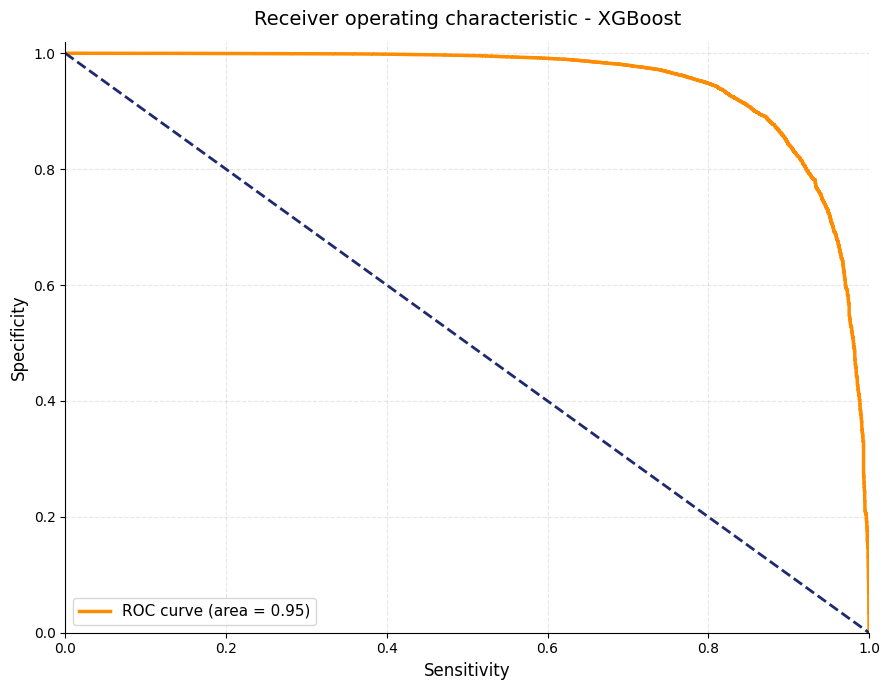

In [81]:
fpr, tpr, _ = roc_curve(y_te, test_proba)
specificity = 1 - fpr
sensitivity = tpr

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(sensitivity, specificity, color='#FF8C00', linewidth=2.5,
        label=f'ROC curve (area = {final_test_auc:.2f})')
ax.plot([0, 1], [1, 0], color='#1F2A6E', linestyle='--', linewidth=2)
ax.set_xlabel('Sensitivity', fontsize=12)
ax.set_ylabel('Specificity', fontsize=12)
ax.set_title('Receiver operating characteristic - XGBoost', fontsize=14, pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()